# Guiding Center Motion of an Auroral Ion Using a Physics-Informed Neural Network (PINN) #

## Problem Overview ##
Guiding Center Motion describes the motion of an electrically-charged particle in a magnetic field which can be treated as the superposition of a relatively fast circular motion around a point (called the guiding center) and a relatively slow drift of this point. The inspiration for this notebook is heavily drawn from Mushrafi Shushmit's excellent work [here](https://github.com/mushrafi88/Physics-Informed-Neural-Networks-for-Quantum-Dynamics).

The equation of motion for such a particle can be obtained from the Lorentz Force:
$$ m\frac{d^2 \mathbf{x}}{dt^2} - q\left(\mathbf{E} + \mathbf{v}\times\mathbf{B}\right) = 0 $$

where $q$ is the particle charge, $\mathbf{E}$ is the electric field and $\mathbf{B}$ is the magnetic field.

This results in a drift velocity due to the ionospheric electric field is of the following form:
$$ \mathbf{v}_E = \frac{\mathbf{E}\times\mathbf{B}}{B^2} $$
If we treat the electric and magnetic fields as mutually perpendicular and uniform, we have the following [exact solution](https://hiddensymmetries.princeton.edu/sites/g/files/toruqf1546/files/pedersen_-_particle_orbits.pdf) for position in three dimensions:
$$ x(t) = x_{gc} + \frac{v_{\perp}}{\omega_{c}}\sin{\left(\omega_c t + \delta\right)} $$ 
$$ y(t) = y_{gc} + \frac{v_{\perp}}{\omega_{c}}\cos{\left(\omega_c t + \delta\right)} $$
$$ z(t) = z_0 + v_{\parallel}t $$
where the cyclotron frequency is
$$ \omega_c = \frac{qB_0}{m}$$
and $x_{gc}, y_{gc}$ are positions of the guiding center and $v_{\parallel}$ is the velocity parallel to the magnetic field.

Due to the constancy of the fields, we will only have motion of the guiding center in the x-direction. It is also convenient to notice that the Lorentz Force takes the form of a damped harmonic oscillator. If the magnetic field is NOT uniform but instead increases in intensity (which is the case for an ion approaching the poles; something like $B(t) = B_0\left(\frac{t}{1000}\right)$), we can expect instead the position equations for $x$ and $y$ to be akin to the following:
$$ x(t) = x_{gc} + e^{-\lambda t}\frac{v_{\perp}}{\omega_{c}}\sin{\left(\omega_c t + \delta\right)} $$ 
$$ y(t) = y_{gc} + e^{-\lambda t}\frac{v_{\perp}}{\omega_{c}}\cos{\left(\omega_c t + \delta\right)}, $$
where $\lambda<\omega_0$ and $\omega_c=\sqrt{\omega_0^2 - \lambda^2}$. This is simply a damped harmonic oscillator and represents the fact that magnetic fields of increasing strength cause the Larmour radius (explained below) to decrease.

We will set the electric field strength to 50 mV/m, the magnetic field strength to 50,000 nT and note that the Larmour radius is 
$$ r_L = \frac{v_{\perp}}{\omega_c}. $$
Typical values of $v_{\perp}$ for auroral ions are on the order of 100 m/s. We will consider an He$^+$ ion with a mass of $6.6\times10^{-27}$ kg and charge of $1.60217663\times10^{-19}$ C. This yields $\omega_c = 1213.77018$ s$^{-1}$ and $r_{L}\approx0.0824$ m.

We will consider the following initial conditions:
$$ x(0) = 0, y(0) = 0 $$
and limit ourselves to considering the $x$ and $y$ components.

Lastly, we note:
$$ v_{x,gc}(0) = -1000\ \mathrm{m/s} \implies x_{gc}=x(0)+v_{x,gc}t. $$

### Making directories for results ###

In [1]:
import os
if not os.path.exists("loss_data"):
    os.makedirs("loss_data")
if not os.path.exists("model_weights"):
    os.makedirs("model_weights")
if not os.path.exists("results"):
    os.makedirs("results")

### Imports ###

In [2]:
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

### Helper Functions ###

In [3]:
def save_gif_PIL(outfile, files, fps=5, loop=0):
    "Helper function for saving GIFs"
    imgs = [Image.open(file) for file in files]
    imgs[0].save(fp=outfile, format='GIF', append_images=imgs[1:], save_all=True, duration=int(1000/fps), loop=loop)

def plot_result(t, x, y, t_data, x_data, y_data, xh, yh, tlim_low, tlim_high, xlim_low, xlim_high, ylim_low, ylim_high, xp=None):
    "Pretty plot training results"
    ax = plt.figure(figsize=(8,4)).add_subplot(projection='3d')
    ax.plot(t, x, y, color="grey", linewidth=2, alpha=0.8, label="Exact solution")
    ax.plot(t, xh, yh, color="tab:blue", linewidth=3, alpha=0.8, label="Neural network prediction")
    ax.scatter(t_data, x_data, y_data, s=60, color="tab:orange", alpha=0.4, label='Training data')
    if xp is not None:
        ax.scatter(xp, -0*torch.ones_like(xp), s=60, color="tab:green", alpha=0.4,
                    label='Physics loss training locations')
    l = ax.legend(loc=(1.01,0.34), frameon=False, fontsize="large")
    ax.setp(l.get_texts(), color="k")
    ax.set_xlim(tlim_low, tlim_high)
    ax.set_ylim(xlim_low, xlim_high)
    ax.set_zlim(ylim_low, ylim_high)
    ax.text(1.065,0.7,"Training step: %i"%(i+1),fontsize="xx-large",color="k")
    ax.axis("off")

### Define a Connected Network Class ###

In [4]:
class FCN(nn.Module):
    "Defines a connected network"
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

### Generate Training Data ###

Use $\delta = \pi/4$, $\omega_0=1000$, and attempt to learn the solution over the domain $t\in[0,0.05]$.

torch.Size([1000, 1]) torch.Size([1000, 1]) torch.Size([1000, 1])


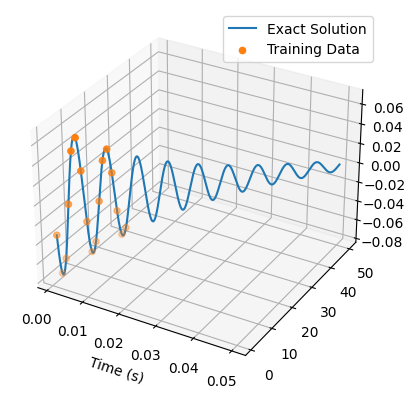

In [5]:
# Constants (all in base SI units)
d = np.pi/4
mass = 6.6e-24 # Grams
charge = 1.60217663e-19 # Coloumbs
omega_c = 1213.77018 # s^-1
radius = 0.0824 # m
v_perp = 100 # m/s
v_x_gc = 1000 # m/s
omega_0 = 1215 # s^-1

# Guiding Center Function
def guidingCenter(t, delta, omega_0):
    # lambda:
    lam = np.sqrt(omega_0**2 - omega_c**2)
    # x-direction:
    x = v_x_gc*t + torch.exp(-lam * t) * (v_perp / omega_c) * torch.sin(omega_c * t + delta)
    # y-direction:
    y = torch.exp(-lam * t) * (v_perp / omega_c) * torch.cos(omega_c * t + delta)
    # Output:
    return x, y

# Get the analytical solution over the full domain:
t_vals = torch.linspace(0.001,0.05,1000).view(-1,1)
x_true, y_true = guidingCenter(t_vals, d, omega_0)
print(t_vals.shape, x_true.shape, y_true.shape)

# Slice out a small number of points from the domain:
t_slice = t_vals[0:250:15]
x_slice = x_true[0:250:15]
y_slice = y_true[0:250:15]

# Show the analytical solution and the training data:
ax = plt.figure().add_subplot(projection='3d')
ax.plot(t_vals, x_true, y_true, label='Exact Solution')
ax.scatter(t_slice, x_slice, y_slice, color='tab:orange', label='Training Data')
ax.set_xlabel('Time (s)')
plt.legend()

### PINN ###
Now we add the underlying differential (encapsulating so-called "physics loss") to the loss function.

In [6]:
# Sample locations over the problem domain:
t_physics = torch.linspace(0,0.05,50).view(-1,1).requires_grad_(True)
E_field = 0.05
B_0 = 0.00005 
def v_x(t, omega_c=omega_c, delta=d):
    return v_perp * np.cos(omega_c * t + delta)
def v_y(t, omega_c=omega_c, delta=d):
    return -v_perp * np.sin(omega_c * t + delta)
def B_field(t):
    return B_0 * ( t / 1000)

torch.manual_seed(123)
torch.set_grad_enabled(True)
model = FCN(1,2,32,3)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-5)
files = []

data_loss_history = []
physics_loss_history = []
total_loss_history = []

# Iteratively train the model:
n_iterations = 25000
for i in range(n_iterations):
    optimizer.zero_grad()

    # Compute the "data loss"
    out = model(t_slice)
    xh = np.squeeze(out[:,0])
    yh = np.squeeze(out[:,1])
    loss_x_1 = torch.mean((xh - np.squeeze(x_slice))**2)
    loss_y_1 = torch.mean((yh - np.squeeze(y_slice))**2)

    # Compute the "physics loss"
    out2 = model(t_physics)
    xhp = np.squeeze(out2[:,0])
    yhp = np.squeeze(out2[:,1])
    dx = torch.autograd.grad(xhp, np.squeeze(t_physics), torch.ones_like(xhp), create_graph=True, retain_graph=True, allow_unused=True)[0] # computes dx/dt
    dx2 = torch.autograd.grad(dx, np.squeeze(t_physics), torch.ones_like(dx), create_graph=True, retain_graph=True, allow_unused=True)[0] # computes dx2/dt2
    #
    dy = torch.autograd.grad(yhp, np.squeeze(t_physics), torch.ones_like(yhp), create_graph=True, retain_graph=True, allow_unused=True)[0] # computes dy/dt
    dy2 = torch.autograd.grad(yp, np.squeeze(t_physics), torch.ones_like(dy), create_graph=True, retain_graph=True, allow_unused=True)[0] # computes dy2/dt2
    # Compute the residual of the oscillator equations in each spatial coordinate:
    physics_x = dx2 - charge*E_field - charge*v_x(t_physics)*B_field(t_physics)
    loss_x_2 = (1e-5) * torch.mean(physics_x**2)
    physics_y = dy2 - charge*E_field - charge*v_y(t_physics)*B_field(t_physics)
    loss_y_2 = (1e-5) * torch.mean(physics_y**2)

    # Backpropagate the joint loss
    loss_x_total = loss_x_1 + loss_x_2
    loss_y_total = loss_y_1 + loss_y_2
    loss = loss_x_total + loss_y_total
    loss_physics = loss_x_2 + loss_y_2

    data_loss_history.append((loss_x_1 + loss_y_1).item())
    total_loss_history.append(loss.item())
    physics_loss_history.append(loss_physics.item())

    loss.retain_grad()
    loss.backward()
    optimizer.step()

    # Plot the result as training progresses
    if (i+1) % 150 == 0:

        out = model(t_vals)
        xh = np.squeeze(out[:,0].detach().numpy())
        yh = np.squeeze(out[:,1].detach().numpy())
        xp = t_physics.detach()
        tlim_low = 0
        tlim_high = 0.05
        xlim_low = 0
        xlim_high = 75
        ylim_low = -0.08
        ylim_high = -0.08
        plot_result(t_vals, x_true, y_true, t_slice, x_slice, y_slice, xh, yh, tlim_low, tlim_high, xlim_low, xlim_high, ylim_low, ylim_high, xp)

        file = "chm_pinn_%.8i.png"%(i+1)
        plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
        files.append(file)

        if (i+1) % 6000 == 0: plt.show()
        else: plt.close("all")

save_gif_PIL("results/chm_pinn.gif", files, fps=20, loop=0)

TypeError: ones_like(): argument 'input' (position 1) must be Tensor, not NoneType